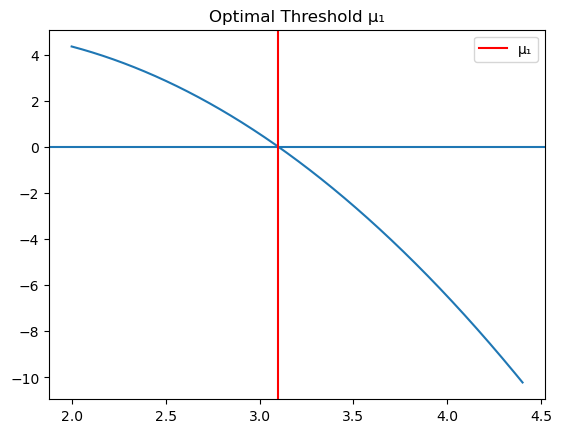

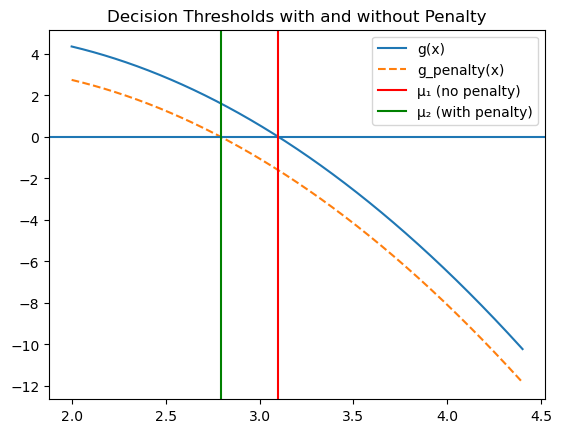

x    P(w0|x)     P(w1|x)     g(x)     Class
3.3  0.7700      0.2300      -1.2083    0
4.4  1.0000      0.0000      -10.2227    0
1.2  0.0064      0.9936      5.0432    1
5.0  1.0000      0.0000      -16.8029    0
5.7  1.0000      0.0000      -25.9636    0
6.3  1.0000      0.0000      -35.0875    0
1.5  0.0065      0.9935      5.0307    1


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.stats import norm

# -------------------------------
# Load and prepare data
# -------------------------------
iris = load_iris()
X = iris.data
y = iris.target

# Select Setosa (0) and Versicolour (1)
mask = y < 2
X = X[mask]
y = y[mask]

# Feature 0 = sepal length
x = X[:, 1]

x0 = x[y == 0]   # Class 0
x1 = x[y == 1]   # Class 1

# Gaussian parameters
mu0, sigma0 = np.mean(x0), np.std(x0)
mu1, sigma1 = np.mean(x1), np.std(x1)

# Priors
P0 = len(x0) / len(x)
P1 = len(x1) / len(x)

# -------------------------------
# Discriminant function
# -------------------------------
def g(x):
    return (np.log(norm.pdf(x, mu1, sigma1)) + np.log(P1)) - \
           (np.log(norm.pdf(x, mu0, sigma0)) + np.log(P0))

def classify(x):
    return np.where(g(x) > 0, 1, 0)

def posteriors(x):
    p0 = norm.pdf(x, mu0, sigma0) * P0
    p1 = norm.pdf(x, mu1, sigma1) * P1
    total = p0 + p1
    return p0 / total, p1 / total

# -------------------------------
# Find optimal threshold μ₁
# -------------------------------
xs = np.linspace(min(x), max(x), 1000)
gx = g(xs)

idx1 = np.argmin(np.abs(gx))
mu_1 = xs[idx1]

plt.plot(xs, gx)
plt.axhline(0)
plt.axvline(mu_1, color='r', label='μ₁')
plt.title("Optimal Threshold μ₁")
plt.legend()
plt.show()

# -------------------------------
# High-penalty case → μ₂
# -------------------------------
lambda_10 = 5  # high penalty for misclassifying w1 as w0

def g_penalty(x):
    return (np.log(norm.pdf(x, mu1, sigma1)) + np.log(P1)) - \
           (np.log(norm.pdf(x, mu0, sigma0)) + np.log(P0) + np.log(lambda_10))

gx_pen = g_penalty(xs)
idx2 = np.argmin(np.abs(gx_pen))
mu_2 = xs[idx2]

# -------------------------------
# Plot μ₁ vs μ₂
# -------------------------------
plt.plot(xs, gx, label='g(x)')
plt.plot(xs, gx_pen, '--', label='g_penalty(x)')
plt.axhline(0)
plt.axvline(mu_1, color='r', label='μ₁ (no penalty)')
plt.axvline(mu_2, color='g', label='μ₂ (with penalty)')
plt.legend()
plt.title("Decision Thresholds with and without Penalty")
plt.show()

# -------------------------------
# Test table
# -------------------------------
test_x = [3.3, 4.4, 1.2, 5.0, 5.7, 6.3, 1.5]

print("x    P(w0|x)     P(w1|x)     g(x)     Class")
for val in test_x:
    p0, p1 = posteriors(val)
    print(f"{val:.1f}  {p0:.4f}      {p1:.4f}      {g(val):.4f}    {classify(val)}")
